# Exercise 8-1: Analyze the NSF Awards data

## Read the data

In [1]:
import pandas as pd
import datetime

data_dir = '../../data'

In [2]:
awards_df = pd.read_pickle(f'{data_dir}/pkl_files/awards_data_2010_2025.pkl')

### Reshape the Data Frame for this exercise

In [3]:
# Change date columns to datetime
awards_df = awards_df.astype({'awd_eff_date': 'datetime64[ns]', 'awd_exp_date': 'datetime64[ns]', 'awd_min_amd_letter_date': 'datetime64[ns]', 'awd_max_amd_letter_date': 'datetime64[ns]'})

In [4]:
# Add awd_month and awd_year columns
awards_df['awd_monthnum'] = awards_df['awd_eff_date'].dt.month
awards_df['awd_month'] = awards_df['awd_eff_date'].dt.month_name()
awards_df['awd_year'] = awards_df['awd_eff_date'].dt.year

In [5]:
# Get rid of most of the columns
awards_df = awards_df[['dir_abbr', 'awd_year', 'awd_monthnum', 'awd_month', 'awd_id', 'awd_amount']]
# Add a column for the number of awards
awards_df['awd_count'] = 1

In [6]:
awards_df.head()

,dir_abbr,awd_year,awd_monthnum,awd_month,awd_id,awd_amount,awd_count
0,MPS,2010,1,January,0415302,146000000.0,1
1,EDU,2009,12,December,0731599,10000.0,1
2,MPS,2010,9,September,0804541,155998.0,1
3,MPS,2010,4,April,0805878,196001.0,1
4,MPS,2010,9,September,0805989,196252.0,1


### Wide version of the data

In [18]:
awards_wide_df = awards_df.pivot_table(index=['dir_abbr'], columns='awd_year', values='awd_amount', aggfunc='sum').reset_index()

In [20]:
awards_wide_df.head(20)

awd_year,dir_abbr,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
0,BFA,NaN,NaN,3.350885e+06,5.598790e+05,1.317168e+06,9.465590e+05,3.014470e+06,8.356830e+05,1.126021e+06,8.623370e+05,2.300890e+06,3.274493e+06,1.947965e+06,2.105040e+06,2.377470e+06,NaN,NaN,NaN,NaN
1,BIO,NaN,59480192.0,8.032351e+08,1.077887e+09,5.780458e+08,7.624332e+08,6.513569e+08,6.603267e+08,1.000118e+09,1.024936e+09,6.579454e+08,6.591381e+08,8.000637e+08,8.817895e+08,7.630074e+08,8.395965e+08,595357831.0,122278582.0,2160000.0
2,CSE,463433.0,12051109.0,8.926897e+08,8.292819e+08,7.814189e+08,1.035275e+09,8.011874e+08,9.109248e+08,1.012625e+09,8.787379e+08,1.069197e+09,1.202820e+09,1.091327e+09,1.116510e+09,1.051493e+09,1.054025e+09,805756689.0,155694943.0,600000.0
3,EDU,NaN,12223851.0,1.151891e+09,1.432733e+09,1.053353e+09,8.750860e+08,8.101119e+08,7.868248e+08,1.377909e+09,1.293440e+09,1.391185e+09,1.052834e+09,1.134095e+09,1.602267e+09,1.155589e+09,8.172164e+08,838175584.0,84790865.0,NaN
4,ENG,300000.0,18623589.0,6.270848e+08,6.649004e+08,6.759034e+08,4.949984e+08,5.253518e+08,8.281208e+08,7.180553e+08,7.854742e+08,6.771363e+08,6.433240e+08,9.111560e+08,9.060344e+08,7.888189e+08,7.123550e+08,659459856.0,111612106.0,NaN
5,GEO,64257.0,303251658.0,1.316559e+09,8.410367e+08,1.466416e+09,1.008361e+09,1.361291e+09,6.690332e+08,7.251976e+08,1.164946e+09,2.795297e+09,1.045543e+09,7.984804e+08,9.812849e+08,8.478075e+08,8.525109e+08,492738002.0,196146626.0,NaN
6,IRM,NaN,414141.0,5.096555e+06,9.037900e+06,3.326208e+06,7.485957e+06,9.747510e+05,2.052460e+07,2.766189e+06,8.312492e+06,6.589796e+07,8.501657e+06,3.100581e+07,8.805089e+06,1.067607e+07,NaN,NaN,NaN,NaN
7,MPS,113753.0,836638883.0,1.656560e+09,1.278042e+09,1.175045e+09,1.047616e+09,1.857293e+09,1.472106e+09,1.962476e+09,1.355278e+09,1.742191e+09,1.220878e+09,1.706057e+09,1.400433e+09,1.348766e+09,1.336669e+09,922213999.0,115792826.0,NaN
8,NCO,NaN,NaN,NaN,NaN,NaN,NaN,2.837870e+05,NaN,NaN,NaN,1.781772e+06,1.650000e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NNCO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.444110e+05,NaN,0.000000e+00,1.724051e+06,1.350000e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## The melt() method

In [21]:
awards_melted_df = awards_wide_df.melt(id_vars=['dir_abbr'], var_name='awd_year', value_name='awd_amount')
awards_melted_df.head(20)

,dir_abbr,awd_year,awd_amount
0,BFA,2008,NaN
1,BIO,2008,NaN
2,CSE,2008,463433.0
3,EDU,2008,NaN
4,ENG,2008,300000.0
5,GEO,2008,64257.0
6,IRM,2008,NaN
7,MPS,2008,113753.0
8,NCO,2008,NaN
9,NNCO,2008,NaN


c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


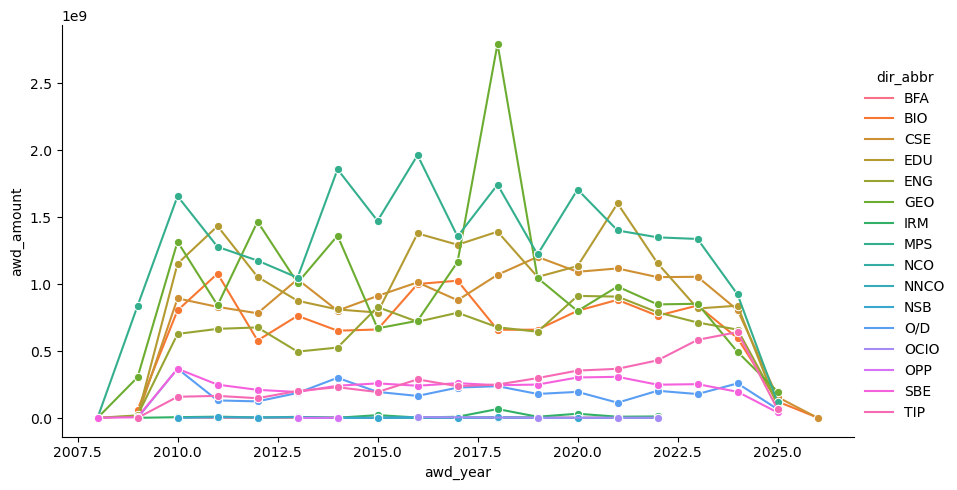

In [23]:
# Plot the melted data
import seaborn as sns

sns.relplot(data=awards_melted_df, x='awd_year', y='awd_amount', hue='dir_abbr', kind='line', aspect=1.75, marker='o')

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

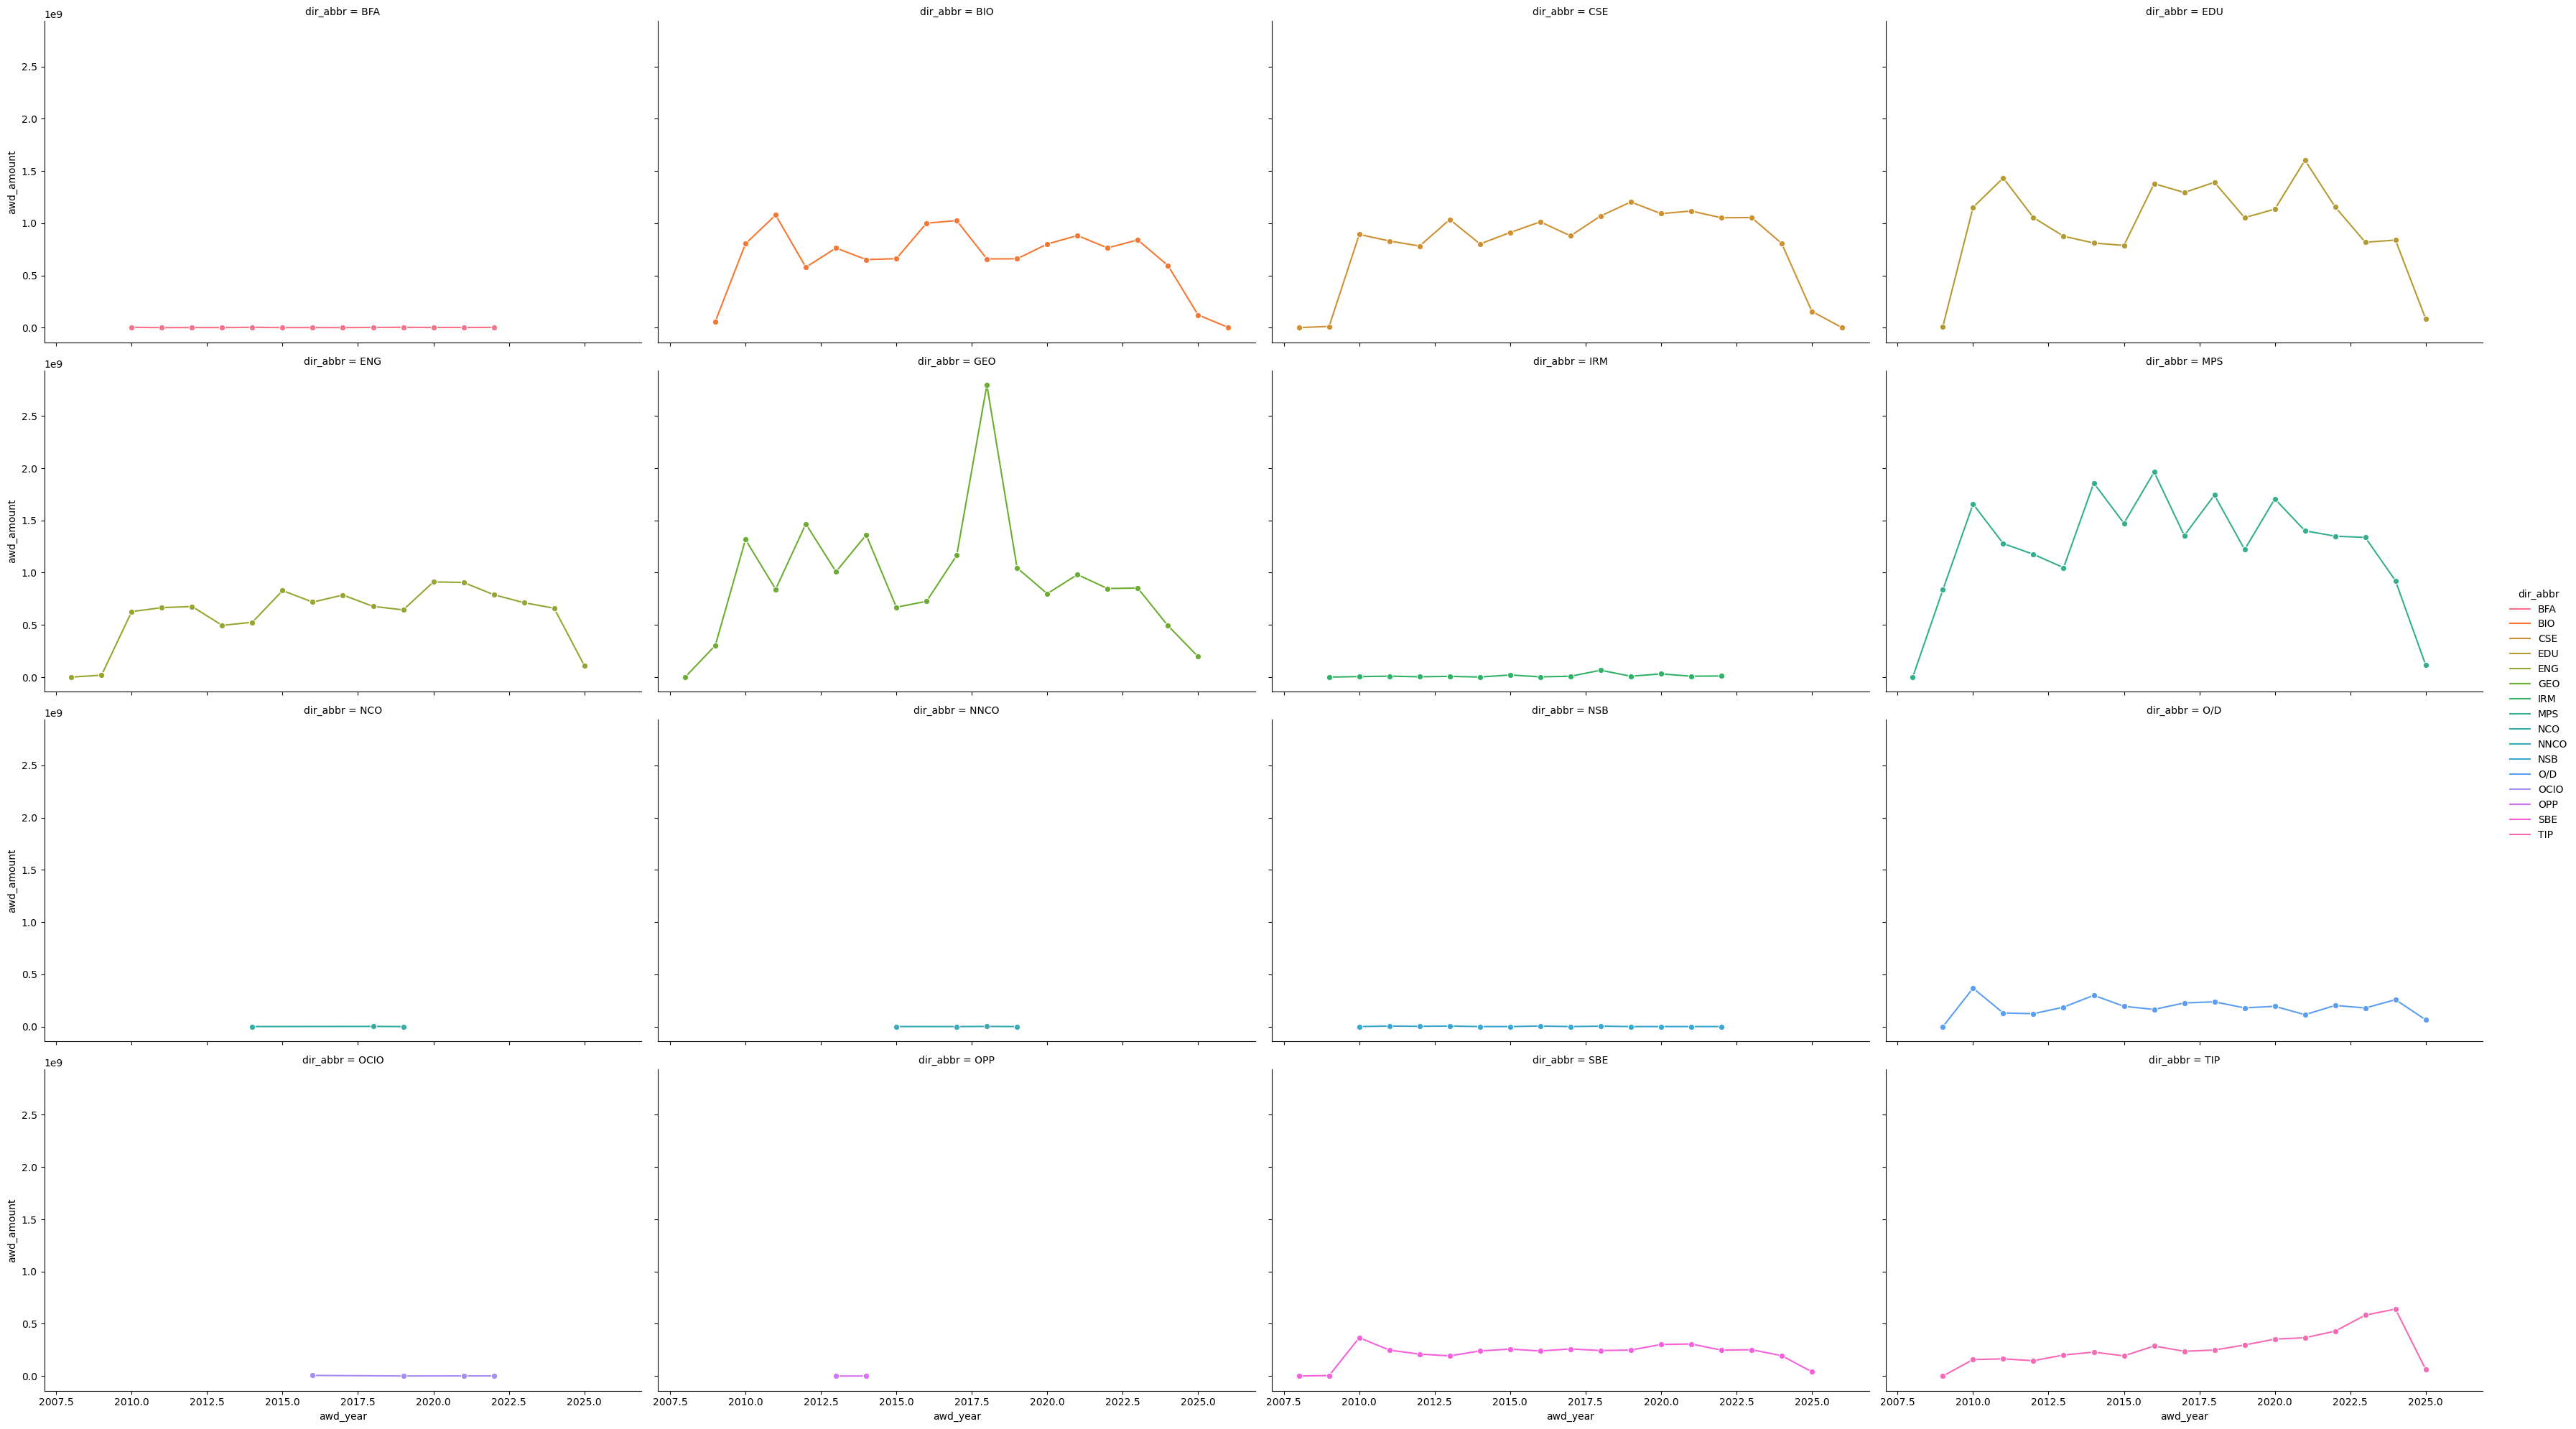

In [25]:
# Plot the melted data with the col parameter
sns.relplot(data=awards_melted_df, x='awd_year', y='awd_amount', hue='dir_abbr', kind='line', aspect=1.75, marker='o', col='dir_abbr', col_wrap=4)

## Group and aggregate the data

In [32]:
awards_df.sort_values(by=['dir_abbr','awd_year', 'awd_monthnum'], ascending=[True, True, True], inplace=True)
awards_df.head(20)

,dir_abbr,awd_year,awd_monthnum,awd_month,awd_id,awd_amount,awd_count
8791,BFA,2010,1,January,1019712,24788.0,1
8837,BFA,2010,1,January,1019954,23722.0,1
11502,BFA,2010,3,March,1035549,200000.0,1
11820,BFA,2010,5,May,1037979,194262.0,1
12043,BFA,2010,5,May,1039575,15144.0,1
12415,BFA,2010,6,June,1041794,89973.0,1
12667,BFA,2010,6,June,1043513,31490.0,1
13090,BFA,2010,8,August,1049278,934107.0,1
13536,BFA,2010,8,August,1058407,44444.0,1
13586,BFA,2010,9,September,1059239,81216.0,1


In [34]:
awards_df.groupby('dir_abbr')[['awd_amount','awd_count']].mean().head()

,awd_amount,awd_count
dir_abbr,,
BFA,2.223969e+05,1.0
BIO,6.078690e+05,1.0
CSE,4.974818e+05,1.0
EDU,1.006067e+06,1.0
ENG,4.005034e+05,1.0


In [36]:
# Max value by month and dir_abbr
awards_df.groupby(['dir_abbr', 'awd_year', 'awd_monthnum'])[['awd_amount']].max().head(20)

awd_amount
dir_abbr awd_year awd_monthnum            
BFA      2010     1                24788.0
                  3               200000.0
                  5               194262.0
                  6                89973.0
                  8               934107.0
                  9               367060.0
                  11             1344679.0
         2011     6               269919.0
                  8                24630.0
                  9                44444.0
         2012     5               210000.0
                  6               479366.0
                  7                27320.0
         2013     6               416594.0
                  7               132262.0
                  8               370923.0
                  9                26780.0
         2014     5              1617842.0
                  6               467754.0
                  7               139094.0

In [7]:
# Group the awards_df DataFrame by 'dir_abbr' and 'awd_year' columns
# This will allow us to perform aggregation operations (e.g., sum, mean) on the grouped data
awards_grouped = awards_df.groupby(['dir_abbr', 'awd_year'])

In [39]:
# Aggregate the grouped data by summing up the numeric columns
awards_by_year = awards_grouped.sum()
awards_by_year.head(3)

awd_monthnum  \
dir_abbr awd_year                 
BFA      2010                72   
         2011                38   
         2012                30   

                                                           awd_month  \
dir_abbr awd_year                                                      
BFA      2010      JanuaryJanuaryMarchMayMayJuneJuneAugustAugustS...   
         2011                       JuneJuneAugustSeptemberSeptember   
         2012                                    MayJuneJuneJuneJuly   

                                                              awd_id  \
dir_abbr awd_year                                                      
BFA      2010      1019712101995410355491037979103957510417941043...   
         2011                    11399011140249115293911567841157476   
         2012                    12406011242711124298212448561247855   

                   awd_amount  awd_count  
dir_abbr awd_year                         
BFA      2010       3350885.0         12  
         2011        559879.0          5  
         2012       1317168.0          5

In [40]:
# Drop unnecessary columns to simplify the DataFrame
awards_by_year.drop(columns=['awd_month', 'awd_monthnum', 'awd_id'], inplace=True)
awards_by_year.reset_index(inplace=True)
awards_by_year.head(3)

,dir_abbr,awd_year,awd_amount,awd_count
0,BFA,2010,3350885.0,12
1,BFA,2011,559879.0,5
2,BFA,2012,1317168.0,5


In [41]:
awards_grouped.awd_amount.agg(['sum', 'mean', 'min', 'max']).head(3)

sum           mean       min        max
dir_abbr awd_year                                               
BFA      2010      7199213.0  599934.416667  197744.0  1580012.0
         2011      1051346.0  210269.200000   10000.0   470992.0
         2012      2094538.0  418907.600000   10000.0  1240246.0

In [43]:
awards_grouped.agg({'awd_count':'sum', 'awd_amount':['sum', 'mean']}).head(3)

awd_count awd_amount               
                        sum        sum           mean
dir_abbr awd_year                                    
BFA      2010            12  7199213.0  599934.416667
         2011             5  1051346.0  210269.200000
         2012             5  2094538.0  418907.600000

## Use pivot tables

In [44]:
# Filter the awards_by_year DataFrame to include only rows where awd_year is greater than or equal to 2022
# and reset the index for the resulting DataFrame
awards_recent = awards_by_year.query('awd_year >= 2022').reset_index()
awards_recent.head(5)

,index,dir_abbr,awd_year,awd_amount,awd_count
0,12,BFA,2022,2377470.0,13
1,26,BIO,2022,763007359.0,1198
2,27,BIO,2023,839596545.0,1115
3,28,BIO,2024,595357831.0,1018
4,29,BIO,2025,122278582.0,272


In [11]:
# Create a pivot table to display the award amounts by directorate (dir_abbr) and year (awd_year)
awards_recent.pivot(index='dir_abbr', columns='awd_year', values='awd_amount').head()

awd_year,2022,2023,2024,2025,2026
dir_abbr,,,,,
BFA,2.377470e+06,NaN,NaN,NaN,NaN
BIO,7.630074e+08,8.395965e+08,595357831.0,122278582.0,2160000.0
CSE,1.051493e+09,1.054025e+09,805756689.0,155694943.0,600000.0
EDU,1.155589e+09,8.172164e+08,838175584.0,84790865.0,NaN
ENG,7.888189e+08,7.123550e+08,659459856.0,111612106.0,NaN


In [45]:
# Create a pivot table to display the number of awards (awd_count) by directorate (dir_abbr) and year (awd_year) for years >= 2022
awards_df.query('awd_year >= 2022').pivot_table(
    index='dir_abbr', columns='awd_year', values='awd_count', aggfunc='sum').head(10)

awd_year,2022,2023,2024,2025,2026
dir_abbr,,,,,
BFA,13.0,NaN,NaN,NaN,NaN
BIO,1198.0,1115.0,1018.0,272.0,8.0
CSE,2027.0,2115.0,1724.0,367.0,1.0
EDU,1211.0,1152.0,1314.0,113.0,NaN
ENG,1721.0,1689.0,1628.0,293.0,NaN
GEO,1465.0,1392.0,1304.0,353.0,NaN
IRM,15.0,NaN,NaN,NaN,NaN
MPS,2575.0,2673.0,2435.0,470.0,NaN
NSB,7.0,NaN,NaN,NaN,NaN


<Axes: xlabel='dir_abbr'>

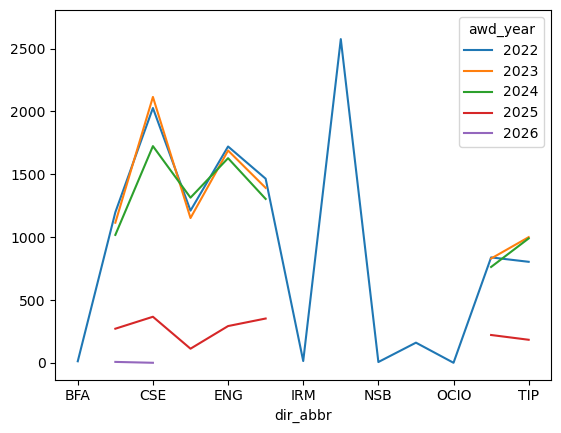

In [ ]:
# Create a pivot table to display the number of awards (awd_count) by directorate (dir_abbr) and year (awd_year) for years >= 2022
awards_df.query('awd_year >= 2022').pivot_table(
    index='dir_abbr', columns='awd_year', values='awd_count', aggfunc='sum').plot()

## Work with bins

In [47]:
# Reset the index of the awards_by_year DataFrame to make it easier to work with
awards_by_year.reset_index(inplace=True)
awards_by_year

,index,dir_abbr,awd_year,awd_amount,awd_count
0,0,BFA,2010,3350885.0,12
1,1,BFA,2011,559879.0,5
2,2,BFA,2012,1317168.0,5
3,3,BFA,2013,946559.0,4
4,4,BFA,2014,3014470.0,6
...,...,...,...,...,...
208,208,TIP,2021,366452493.0,904
209,209,TIP,2022,429729426.0,804
210,210,TIP,2023,582735986.0,1000
211,211,TIP,2024,640899526.0,990


In [49]:
# Create a new column 'decade' in the awards_by_year DataFrame by binning the 'awd_year' column
# into two categories: '2010s' and '2020s', based on specified year ranges
awards_by_year['decade'] = pd.cut(awards_by_year.awd_year, 
                                 bins=[2010,2020,2030], 
                                 labels=['2010s', '2020s'], 
                                 right=False)

In [50]:
awards_by_year.head(25)

,index,dir_abbr,awd_year,awd_amount,awd_count,decade
0,0,BFA,2010,3.350885e+06,12,2010s
1,1,BFA,2011,5.598790e+05,5,2010s
2,2,BFA,2012,1.317168e+06,5,2010s
3,3,BFA,2013,9.465590e+05,4,2010s
4,4,BFA,2014,3.014470e+06,6,2010s
5,5,BFA,2015,8.356830e+05,4,2010s
6,6,BFA,2016,1.126021e+06,8,2010s
7,7,BFA,2017,8.623370e+05,8,2010s
8,8,BFA,2018,2.300890e+06,11,2010s
9,9,BFA,2019,3.274493e+06,11,2010s


In [54]:
# Drop the 'awd_year' column from the awards_by_year DataFrame to prepare for grouping by decade
awards_by_decade = awards_by_year.drop(columns=['awd_year'])
awards_by_decade.head()

,index,dir_abbr,awd_amount,awd_count,decade
0,0,BFA,3350885.0,12,2010s
1,1,BFA,559879.0,5,2010s
2,2,BFA,1317168.0,5,2010s
3,3,BFA,946559.0,4,2010s
4,4,BFA,3014470.0,6,2010s


In [55]:
# Group the awards_by_decade DataFrame by 'dir_abbr' and 'decade' columns and sum the numeric columns
awards_by_decade = awards_by_decade.groupby(['dir_abbr', 'decade']).sum()  
awards_by_decade.reset_index(inplace=True)
awards_by_decade.head(25)

C:\Users\dan\AppData\Local\Temp\ipykernel_43396\943665416.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  awards_by_decade = awards_by_decade.groupby(['dir_abbr', 'decade']).sum()


,dir_abbr,decade,index,awd_amount,awd_count
0,BFA,2010s,45,1.758838e+07,74
1,BFA,2020s,33,6.430475e+06,34
2,BIO,2010s,185,7.875422e+09,13325
3,BIO,2020s,189,4.004254e+09,6235
4,CSE,2010s,375,9.414157e+09,19239
5,CSE,2020s,322,5.275407e+09,10255
6,EDU,2010s,555,1.122537e+10,10564
7,EDU,2020s,381,5.632134e+09,6175
8,ENG,2010s,735,6.640349e+09,18122
9,ENG,2020s,489,4.089436e+09,8650


In [57]:
# Use qcut() to create quantile-based bins for the 'awd_amount' column in the awards_by_year DataFrame
awards_by_year['awd_amount_q'] = pd.qcut(awards_by_decade['awd_amount'],
                                            q=4, 
                                            labels=['very low', 'low', 'medium', 'high'])
awards_by_year.head(25)

,index,dir_abbr,awd_year,awd_amount,awd_count,decade,awd_amount_q
0,0,BFA,2010,3.350885e+06,12,2010s,low
1,1,BFA,2011,5.598790e+05,5,2010s,low
2,2,BFA,2012,1.317168e+06,5,2010s,high
3,3,BFA,2013,9.465590e+05,4,2010s,medium
4,4,BFA,2014,3.014470e+06,6,2010s,high
5,5,BFA,2015,8.356830e+05,4,2010s,medium
6,6,BFA,2016,1.126021e+06,8,2010s,high
7,7,BFA,2017,8.623370e+05,8,2010s,high
8,8,BFA,2018,2.300890e+06,11,2010s,high
9,9,BFA,2019,3.274493e+06,11,2010s,medium


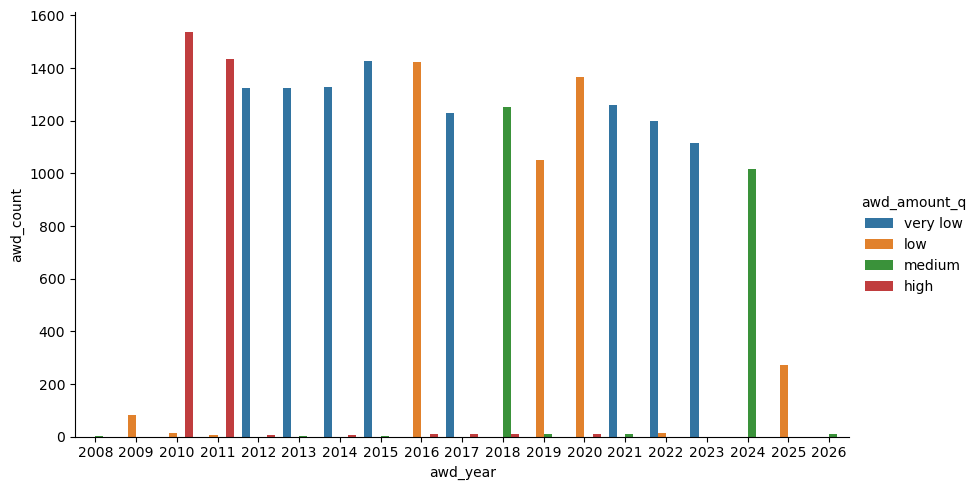

In [58]:
sns.catplot(data=awards_by_year,
             x='awd_year', 
             y='awd_count', 
             hue='awd_amount_q', 
             kind='bar', 
             aspect=1.75, 
             height=5)

## nlargest()

In [60]:
# use nlargest() with the awards_by_year dataframe to get the top 5 dir_abbr for each year
awards_by_year.groupby('awd_year').apply(lambda x: x.nlargest(5, 'awd_amount')).reset_index(drop=True).sort_values(by=['awd_year', 'awd_amount'], ascending=[True, False]).head(25)

,index,dir_abbr,awd_year,awd_amount,awd_count,decade,awd_amount_q
0,178,SBE,2008,6.231750e+05,3,NaN,NaN
1,31,CSE,2008,4.634330e+05,3,NaN,medium
2,67,ENG,2008,3.000000e+05,1,NaN,NaN
3,117,MPS,2008,1.137530e+05,1,NaN,NaN
4,85,GEO,2008,6.425700e+04,1,NaN,NaN
5,118,MPS,2009,8.366389e+08,112,NaN,NaN
6,86,GEO,2009,3.032517e+08,59,NaN,NaN
7,13,BIO,2009,5.948019e+07,81,NaN,low
8,68,ENG,2009,1.862359e+07,65,NaN,NaN
9,50,EDU,2009,1.222385e+07,29,NaN,NaN
